In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [5]:
df=pd.read_csv("c:\\Users\\a\\Downloads\\Phone Link\\trends_analysed.csv")

In [ ]:
os.makedirs("outputs", exist_ok=True)


In [6]:
df

,post_id,title,category,score,num_comments,author,collected_at,engagement,is_popular
0,47645432,Introduction to Computer Music (2009) [pdf],technology,122,33,luu,37:39.0,1.270492,False
1,47640728,Show HN: A game where you build a GPU,technology,639,147,Jaso1024,37:40.6,1.230047,True
2,47640875,"LLM Wiki – example of an ""idea file""",technology,146,40,tamnd,37:44.9,1.273973,False
3,47587089,"Zml-smi: universal monitoring tool for GPUs, T...",technology,18,3,steeve,37:48.0,1.166667,False
4,47639779,Show HN: sllm – Split a GPU node with other de...,technology,147,74,jrandolf,37:55.1,1.503401,False
...,...,...,...,...,...,...,...,...,...
70,47612277,Almighty Lisp: Lisp and Emacs Essentials Book,entertainment,75,4,nemoniac,11:49.1,1.053333,False
71,47589856,Show HN: Postgres extension for BM25 relevance...,entertainment,202,56,tjgreen,11:56.3,1.277228,True
72,47612321,Show HN: I built a DNS resolver from scratch i...,entertainment,113,65,rdme,12:01.9,1.575221,False
73,47615844,Show HN: A P2P messenger with dual network mod...,entertainment,39,22,Realman78,12:08.6,1.564103,False


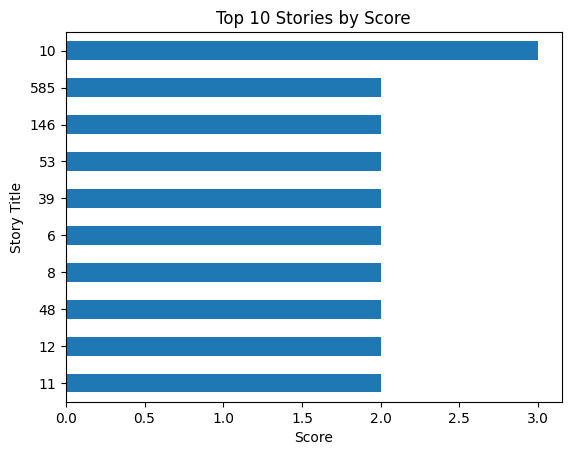

In [21]:
df["score"].value_counts().head(10).plot(kind="barh")
plt.xlabel("Score")
plt.ylabel("Story Title")
plt.title("Top 10 Stories by Score")
plt.gca().invert_yaxis()
plt.savefig("outputs/score_distribution.png")
plt.show()

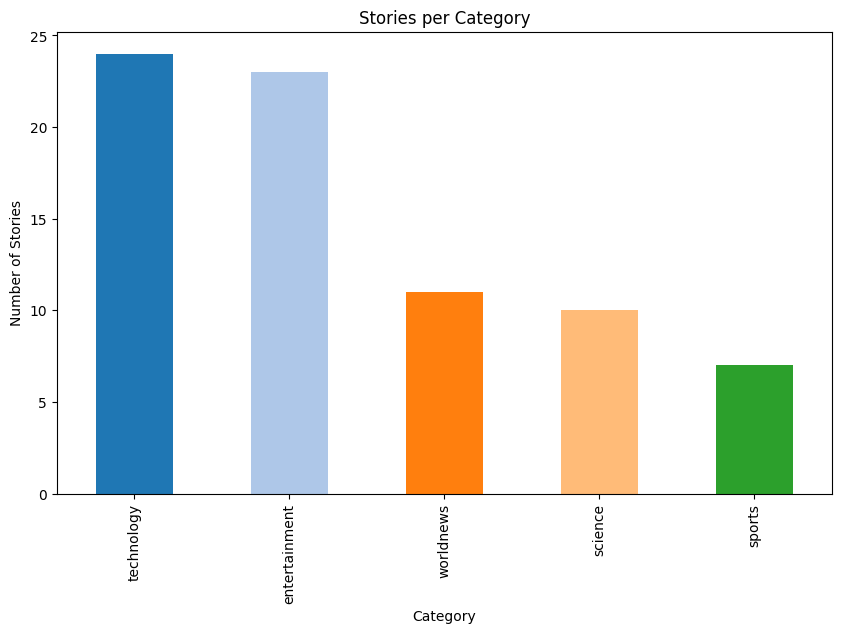

In [55]:
category_counts = df['category'].value_counts()
plt.figure(figsize=(10,6))
category_counts.plot(kind='bar', color=plt.cm.tab20.colors) 
plt.xlabel("Category")
plt.ylabel("Number of Stories")
plt.title("Stories per Category")
plt.savefig("outputs/chart2_category_counts.png", bbox_inches="tight")
plt.show()


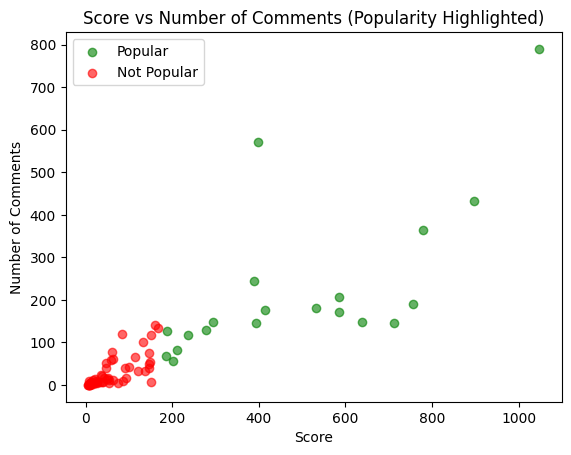

In [44]:
plt.scatter(df[df['is_popular']]['score'],
            df[df['is_popular']]['num_comments'],
            color='green', label='Popular', alpha=0.6)

plt.scatter(df[~df['is_popular']]['score'],
            df[~df['is_popular']]['num_comments'],
            color='red', label='Not Popular', alpha=0.6)
plt.xlabel("Score")
plt.ylabel("Number of Comments")
plt.title("Score vs Number of Comments (Popularity Highlighted)")
plt.legend()
plt.savefig("outputs/chart3_score_vs_comments.png", bbox_inches="tight")
plt.show()

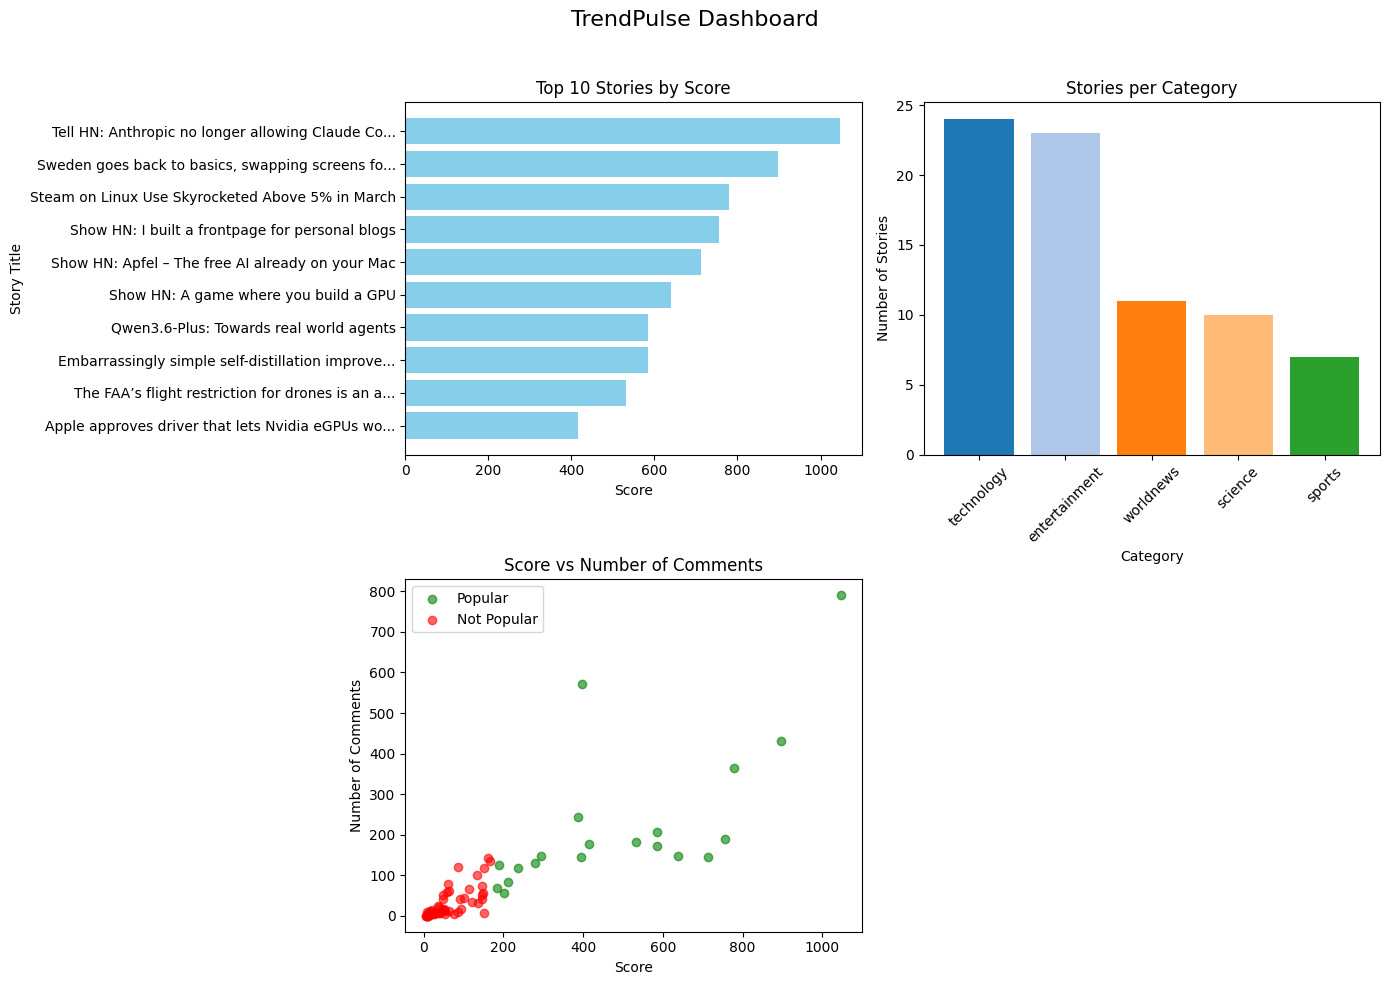

In [54]:

top10 = df.sort_values("score", ascending=False).head(10).copy()
top10["short_title"] = top10["title"].apply(lambda x: x[:47] + "..." if len(x) > 50 else x)


category_counts = df['category'].value_counts()


average_score = df['score'].mean()
df['is_popular'] = df['score'] > average_score


fig, axes = plt.subplots(2, 2, figsize=(14,10))


axes[0,0].barh(top10["short_title"], top10["score"], color="skyblue")
axes[0,0].set_xlabel("Score")
axes[0,0].set_ylabel("Story Title")
axes[0,0].set_title("Top 10 Stories by Score")
axes[0,0].invert_yaxis()

axes[0,1].bar(category_counts.index, category_counts.values, color=plt.cm.tab20.colors)
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Number of Stories")
axes[0,1].set_title("Stories per Category")
axes[0,1].tick_params(axis='x', rotation=45)


axes[1,0].scatter(df[df['is_popular']]['score'],
                  df[df['is_popular']]['num_comments'],
                  color='green', label='Popular', alpha=0.6)
axes[1,0].scatter(df[~df['is_popular']]['score'],
                  df[~df['is_popular']]['num_comments'],
                  color='red', label='Not Popular', alpha=0.6)
axes[1,0].set_xlabel("Score")
axes[1,0].set_ylabel("Number of Comments")
axes[1,0].set_title("Score vs Number of Comments")
axes[1,0].legend()


axes[1,1].axis("off")


fig.suptitle("TrendPulse Dashboard", fontsize=16)


plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("outputs/trendpulse_dashboard.png", bbox_inches="tight")
plt.show()
